# Final Project — AI and Cyber
## Track A — Dataset Project: Edge-IIoTset

**Team members:** Ibrahim Hamed DICKO, Mariam ARKIK, Abdoulaye TOURE
**Course:** AI and Cyber — Sourav Rai
**Random seed used throughout:** `42`

---

This notebook follows the required Track A workflow:
1. Data Acquisition
2. Exploratory Data Analysis (EDA)
3. Model Development and Comparison
4. Hyperparameter Tuning
5. Evaluation

Each section includes the questions asked in the assignment, answered directly in markdown.

## 1. Data Acquisition

### Source
- **Dataset:** Edge-IIoTset — A New Comprehensive Realistic Cyber Security Dataset of IoT
  and IIoT Applications for Centralized and Federated Learning
- **URL:** https://www.kaggle.com/datasets/mohamedamineferrag/edgeiiotset-cyber-security-dataset-of-iot-iiot
- **Paper:** Ferrag, M.A., Friha, O., Hamouda, D., Maglaras, L., Janicke, H. — *IEEE Access*,
  April 2022, DOI: 10.1109/ACCESS.2022.3165809
- **File used:** `DNN-EdgeIIoT-dataset.csv` (the "Selected dataset for ML and DL" — pre-extracted
  flow features, as opposed to the raw PCAPs)

### Domain context — what does this dataset represent?

The dataset was generated from a **physical 7-layer IIoT/Edge testbed** (Cloud, Network
Function Virtualization, Blockchain, Fog, Software-Defined Networking, Edge Computing, and
IoT/IIoT Perception layers), using **more than 10 real IoT device types** (temperature/humidity
sensors, ultrasonic sensors, flame sensors, pH meters, heart-rate sensors, etc.) communicating
over a mix of **IT protocols (TCP/IP, UDP, ICMP, HTTP, DNS, ARP)** and **OT/IIoT protocols
(MQTT, Modbus/TCP)**.

Traffic was captured at the edge gateway and exported as **61 flow-level features** plus two
label columns:
- `Attack_label` — **binary** target (0 = normal, 1 = attack)
- `Attack_type` — **multiclass** target (Normal + 14 attack types)

**14 attack types, grouped into 5 categories** (as defined in the original paper):

| Category | Attack types |
|---|---|
| DoS / DDoS | DDoS_UDP, DDoS_ICMP, DDoS_TCP, DDoS_HTTP |
| Information gathering | Port_Scanning, Vulnerability_scanner, Fingerprinting |
| Man-in-the-Middle | MITM |
| Injection | SQL_injection, XSS, Uploading |
| Malware | Backdoor, Ransomware, Password |

**Why this matters for security:** unlike CLaMP (static, file-level), this is a **network
flow-level IDS dataset** — the kind of data a SOC's NIDS/SIEM would process in real time. The
attack categories map directly onto the **Cyber Kill Chain**: information gathering
(reconnaissance), injection/MITM (exploitation), backdoor/ransomware (installation & actions
on objectives). The inclusion of **MQTT and Modbus** features is what makes this dataset
specifically *industrial* IoT (IIoT) — these are SCADA/PLC protocols rarely seen in
general-purpose network IDS datasets.

### Granularity
**One row = one network flow** (an aggregated sequence of packets between two endpoints),
not a single packet. This is *flow-level*, not file-level (CLaMP) or session-level.

### ⚠️ Scale — read this before downloading

The raw `DNN-EdgeIIoT-dataset.csv` has **2,219,201 rows** and **63 columns**, split
roughly **72.8% Normal / 27.2% attack** at the raw level. This is too large for a free
Colab/laptop kernel to explore comfortably — **we must work from a stratified subset**, per
the project guide's instructions.

### Step 1 — Download the raw file (run once, locally)

```bash
pip install kaggle
# Place your kaggle.json in ~/.kaggle/ (chmod 600), then:
kaggle datasets download -d mohamedamineferrag/edgeiiotset-cyber-security-dataset-of-iot-iiot \
    -f "Edge-IIoTset dataset/Selected dataset for ML and DL/DNN-EdgeIIoT-dataset.csv" \
    -p data/raw --unzip
```

This produces `data/raw/DNN-EdgeIIoT-dataset.csv` (~hundreds of MB — **do not commit this
file to git**, it's in `.gitignore`).

### Step 2 — Create a reproducible stratified sample (run once)

We take a **10% stratified sample on `Attack_type`** (preserves all 15 classes,
including the rare `MITM` class with only ~90 raw rows) and save it as the file this
notebook actually works with.

In [1]:
# --- Run this cell ONCE, after downloading the raw CSV (Step 1 above) ---
# It reads the ~2.2M-row raw file and writes a 10% stratified sample (~220k rows)
# that the rest of this notebook (and your teammates) will use.

import pandas as pd
from sklearn.model_selection import train_test_split

RAW_PATH = "../data/raw/DNN-EdgeIIoT-dataset.csv"
SAMPLE_PATH = "../data/DNN-EdgeIIoT-sample10.csv"

# Uncomment to (re)generate the sample:
# df_full = pd.read_csv(RAW_PATH, low_memory=False)
# df_sample, _ = train_test_split(
#     df_full, train_size=0.10, stratify=df_full["Attack_type"], random_state=42
# )
# df_sample.to_csv(SAMPLE_PATH, index=False)
# print(f"Sample written: {df_sample.shape}")

print("Sampling step — see comments above. Skipped here if the sample already exists.")

Sampling step — see comments above. Skipped here if the sample already exists.


In [2]:
# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    precision_recall_curve, PrecisionRecallDisplay
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

print("Libraries loaded.")

Libraries loaded.


### Data loader function

The official preprocessing notebook (Ferrag et al.) drops 15 columns before modelling.
We adopt the same list, grouped here by **why** each is dropped — this grouping is itself
useful for the "operational challenges" discussion in Section 5:

| Reason for dropping | Columns |
|---|---|
| **Identity leakage** (IP addresses identify specific testbed hosts, not general attack patterns) | `ip.src_host`, `ip.dst_host`, `arp.src.proto_ipv4`, `arp.dst.proto_ipv4` |
| **Timestamps** (not generalizable; risk of temporal leakage) | `frame.time`, `icmp.transmit_timestamp` |
| **Raw payload / high-cardinality strings** (would need NLP-style processing, out of scope) | `http.file_data`, `http.request.full_uri`, `http.request.uri.query`, `tcp.options`, `tcp.payload`, `mqtt.msg` |
| **Port numbers** (testbed-specific; risk of overfitting to fixed ports rather than learning behaviour) | `tcp.srcport`, `tcp.dstport`, `udp.port` |

The function below also separates the **two targets** — `Attack_label` (binary) and
`Attack_type` (multiclass) — as required by the project ("perform both binary and
multiclass classification").

In [3]:
DROP_COLUMNS = [
    # identity leakage
    "ip.src_host", "ip.dst_host", "arp.src.proto_ipv4", "arp.dst.proto_ipv4",
    # timestamps
    "frame.time", "icmp.transmit_timestamp",
    # raw payload / very high-cardinality strings
    "http.file_data", "http.request.full_uri", "http.request.uri.query",
    "tcp.options", "tcp.payload", "mqtt.msg",
    # testbed-specific port numbers
    "tcp.srcport", "tcp.dstport", "udp.port",
]


def load_edge_iiot_data(path="../data/DNN-EdgeIIoT-sample10.csv"):
    """
    Load the Edge-IIoTset stratified sample.

    Returns
    -------
    df : full DataFrame (features + both targets), after dropping leakage columns
    X  : feature DataFrame (both target columns dropped)
    y_binary     : Attack_label (0 = normal, 1 = attack)
    y_multiclass : Attack_type  (Normal + 14 attack types)
    """
    df = pd.read_csv(path, low_memory=False)

    assert "Attack_label" in df.columns, "Expected an 'Attack_label' column"
    assert "Attack_type" in df.columns, "Expected an 'Attack_type' column"

    existing_drops = [c for c in DROP_COLUMNS if c in df.columns]
    df = df.drop(columns=existing_drops)

    X = df.drop(columns=["Attack_label", "Attack_type"])
    y_binary = df["Attack_label"]
    y_multiclass = df["Attack_type"]

    return df, X, y_binary, y_multiclass


df, X, y_binary, y_multiclass = load_edge_iiot_data()
print(f"Loaded {df.shape[0]} rows and {df.shape[1]} columns "
      f"({X.shape[1]} features + 2 targets).")
print(f"\nBinary target (Attack_label) distribution:")
print(y_binary.value_counts(normalize=True).round(3))
print(f"\nMulticlass target (Attack_type) — {y_multiclass.nunique()} classes:")
print(y_multiclass.value_counts())

Loaded 221920 rows and 48 columns (46 features + 2 targets).

Binary target (Attack_label) distribution:
Attack_label
0    0.728
1    0.272
Name: proportion, dtype: float64

Multiclass target (Attack_type) — 15 classes:
Attack_type
Normal                   161564
DDoS_UDP                  12157
DDoS_ICMP                 11644
SQL_injection              5120
Password                   5015
Vulnerability_scanner      5011
DDoS_TCP                   5006
DDoS_HTTP                  4991
Uploading                  3763
Backdoor                   2486
Port_Scanning              2256
XSS                        1592
Ransomware                 1093
MITM                        122
Fingerprinting              100
Name: count, dtype: int64


---
## 2. Exploratory Data Analysis (EDA)

### 2a. Dataset snapshot

In [4]:
print("First 5 rows:")
df.head()

First 5 rows:


,arp.opcode,arp.hw.size,icmp.checksum,icmp.seq_le,icmp.unused,http.content_length,http.request.method,http.referer,http.request.version,http.response,...,mqtt.proto_len,mqtt.protoname,mqtt.topic,mqtt.topic_len,mqtt.ver,mbtcp.len,mbtcp.trans_id,mbtcp.unit_id,Attack_label,Attack_type
0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,SQL_injection
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,DDoS_UDP
2,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,Password
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0,Normal
4,0.0,0.0,0.0,62732.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,DDoS_UDP


In [5]:
print(f"Number of records : {df.shape[0]}")
print(f"Number of columns  : {df.shape[1]}")
print(f"Memory usage       : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print()
df.info()

Number of records : 221920
Number of columns  : 48
Memory usage       : 155.58 MB

<class 'pandas.DataFrame'>
RangeIndex: 221920 entries, 0 to 221919
Data columns (total 48 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   arp.opcode                 221920 non-null  float64
 1   arp.hw.size                221920 non-null  float64
 2   icmp.checksum              221920 non-null  float64
 3   icmp.seq_le                221920 non-null  float64
 4   icmp.unused                221920 non-null  float64
 5   http.content_length        221920 non-null  float64
 6   http.request.method        221920 non-null  str    
 7   http.referer               221920 non-null  str    
 8   http.request.version       221920 non-null  str    
 9   http.response              221920 non-null  float64
 10  http.tls_port              221920 non-null  float64
 11  tcp.ack                    221920 non-null  float64
 12  tcp.ack_raw   

**Question — granularity:** as established in Section 1, each row is **one network
flow** — an aggregated bidirectional exchange between two endpoints over a protocol
(TCP, UDP, ICMP, HTTP, DNS, MQTT, Modbus...). This is *flow-level*, not packet-level: a
single DDoS attack produces **many** near-identical flow rows (one per
connection/burst), which is part of why this dataset is so large and why duplicates
(2c) are expected and meaningful here, unlike in CLaMP.

---

### 2b. Missing-value audit

In [6]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_summary = pd.DataFrame({'n_missing': missing, 'pct_missing': missing_pct})
missing_summary = missing_summary[missing_summary['n_missing'] > 0].sort_values('n_missing', ascending=False)

print(f"Columns with at least one NA: {len(missing_summary)} / {df.shape[1]}")
missing_summary

Columns with at least one NA: 0 / 48


,n_missing,pct_missing


In [7]:
# Near-constant columns (a different kind of "missingness": always the same value,
# e.g. always 0 because the field only applies to one protocol)
nunique = df.nunique()
constant_cols = nunique[nunique <= 1].index.tolist()
print(f"Fully constant columns ({len(constant_cols)}): {constant_cols}")

Fully constant columns (4): ['icmp.unused', 'http.tls_port', 'dns.qry.type', 'mqtt.msg_decoded_as']


**Results:**
- True NA count: _(report the number printed above — likely 0 or very low, since the
  official dataset uses `0` as a placeholder rather than `NaN` for "field not
  applicable to this protocol")_.
- **Fully constant columns** are expected here: prior work on this dataset
  identifies `icmp.unused`, `http.tls_port`, `dns.qry.type`, and `mqtt.msg_decoded_as`
  as always-zero in the DNN-EdgeIIoT file. These carry **zero information** and are
  candidates for dropping in 2g.

**Question — could missing values be related to attack patterns or evasion
techniques?** Here the more useful framing is **"structural sparsity by protocol"**
rather than missingness. A flow only populates the `mqtt.*` fields if it *is* MQTT
traffic; `http.*` fields are populated only for HTTP flows, `mbtcp.*` only for Modbus,
etc. This is itself a **security signal**: the *presence* of non-zero MQTT/Modbus
fields tells you a flow touched the IIoT/OT side of the network — and several attack
types in this dataset (Backdoor, Ransomware, MITM) specifically target those
OT-protocol flows. So "which protocol block is populated" is a feature in its own
right, separate from the raw field values.

---

### 2c. Duplicate check

In [8]:
n_dup = df.duplicated().sum()
print(f"Full-row duplicates: {n_dup} ({n_dup / len(df) * 100:.2f}% of the sample)")

print("\nDuplicate rate by Attack_type:")
dup_by_class = df[df.duplicated(keep=False)]['Attack_type'].value_counts()
total_by_class = df['Attack_type'].value_counts()
(dup_by_class / total_by_class * 100).round(1).sort_values(ascending=False).head(10)

Full-row duplicates: 6350 (2.86% of the sample)

Duplicate rate by Attack_type:


Attack_type
MITM              64.8
Fingerprinting    19.0
DDoS_ICMP         11.9
Port_Scanning     11.3
Ransomware        10.7
Normal             5.4
XSS                4.5
Backdoor           3.9
DDoS_HTTP          0.6
Uploading          0.5
Name: count, dtype: float64

**Result (from the real 221,920-row sample):** 6,350 full-row duplicates
(**2.86%** overall) — but the per-class breakdown tells a different story than the
initial hypothesis:

| Attack_type | Duplicate rate |
|---|---|
| `MITM` | **64.8%** |
| `Fingerprinting` | **19.0%** |
| `DDoS_ICMP` | 11.9% |
| `Port_Scanning` | 11.3% |
| `Ransomware` | 10.7% |
| `Normal` | 5.4% |
| `XSS` | 4.5% |
| `Backdoor` | 3.9% |
| `DDoS_HTTP` | 0.6% |
| `Uploading` | 0.5% |

**Revised interpretation:** "DDoS flood → duplication" only partially holds
(`DDoS_ICMP` at 11.9% fits; `DDoS_HTTP` at 0.6% does **not**). The dominant pattern is
the opposite: **the rarest, most targeted classes (`MITM`, `Fingerprinting`) have by
far the highest duplication**. With only ~122 raw `MITM` flows, 64.8% duplicates
means the testbed effectively captured a handful of distinct `MITM` flow "shapes",
each repeated many times.

**Question — could duplicates represent repeated attack attempts or benign repeated
behaviour?** Yes, but asymmetrically: `MITM`/`Fingerprinting` duplication likely
reflects **a small number of attack "runs"** in the testbed, each producing a burst of
identical flows. `DDoS_ICMP`'s elevated rate (11.9%) fits ICMP echo floods being
extremely uniform at the header level. `DDoS_HTTP`'s near-zero rate (0.6%) suggests
HTTP flood flows vary more (content-length, response codes) even when the underlying
attack repeats.

**Revised decision — and why it matters operationally:** unlike the initial plan
("keep all duplicates"), we **do deduplicate before the train/test split** (2g), for
one critical reason: **leakage risk on the rare classes**. If 65% of `MITM` rows are
exact duplicates and we don't dedupe, a stratified 70/30 split would very likely place
identical `MITM` rows in *both* train and test — the model could "recognise" a row it
memorised during training, inflating `MITM` recall in a way that would **not
generalise** to a genuinely new `MITM` flow in production. Deduplicating costs only
2.86% of the data overall, but removes this leakage risk precisely where it matters
most — a good talking point for the "operational challenges" discussion later.

---

### 2d. Descriptive statistics

In [9]:
# Numeric features
df.describe().T

,count,mean,std,min,25%,50%,75%,max
arp.opcode,221920.0,3.397621e-03,6.954906e-02,0.0,0.00,0.000000e+00,0.000000e+00,2.000000e+00
arp.hw.size,221920.0,1.603280e-02,3.097422e-01,0.0,0.00,0.000000e+00,0.000000e+00,6.000000e+00
icmp.checksum,221920.0,1.719438e+03,8.472136e+03,0.0,0.00,0.000000e+00,0.000000e+00,6.553300e+04
icmp.seq_le,221920.0,1.904900e+03,8.910083e+03,0.0,0.00,0.000000e+00,0.000000e+00,6.552700e+04
icmp.unused,221920.0,0.000000e+00,0.000000e+00,0.0,0.00,0.000000e+00,0.000000e+00,0.000000e+00
http.content_length,221920.0,5.082809e+00,1.857462e+02,0.0,0.00,0.000000e+00,0.000000e+00,8.365500e+04
http.response,221920.0,1.452325e-02,1.196344e-01,0.0,0.00,0.000000e+00,0.000000e+00,1.000000e+00
http.tls_port,221920.0,0.000000e+00,0.000000e+00,0.0,0.00,0.000000e+00,0.000000e+00,0.000000e+00
tcp.ack,221920.0,2.264843e+07,1.633362e+08,0.0,1.00,6.000000e+00,5.900000e+01,3.178709e+09
tcp.ack_raw,221920.0,1.573491e+09,1.338594e+09,0.0,37120903.50,1.421616e+09,2.510532e+09,4.294923e+09


In [10]:
# Categorical features and their cardinality (exclude the targets themselves)
categorical_cols = (df.drop(columns=['Attack_label', 'Attack_type'])
                       .select_dtypes(include=['object', 'string']).columns.tolist())
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}\n")

for c in categorical_cols:
    print(f"{c:25s} -> {df[c].nunique():4d} unique values | top: {df[c].value_counts().head(2).to_dict()}")

Categorical columns (7): ['http.request.method', 'http.referer', 'http.request.version', 'dns.qry.name.len', 'mqtt.conack.flags', 'mqtt.protoname', 'mqtt.topic']

http.request.method       ->    6 unique values | top: {'0.0': 196428, '0': 22291}
http.referer              ->    4 unique values | top: {'0.0': 210326, '0': 11534}
http.request.version      ->    4 unique values | top: {'0.0': 196306, '0': 22413}
dns.qry.name.len          ->    8 unique values | top: {'0': 161382, '0.0': 60335}
mqtt.conack.flags         ->    7 unique values | top: {'0': 153236, '0.0': 60356}
mqtt.protoname            ->    3 unique values | top: {'0': 153239, '0.0': 60356}
mqtt.topic                ->    3 unique values | top: {'0': 153418, '0.0': 60356}


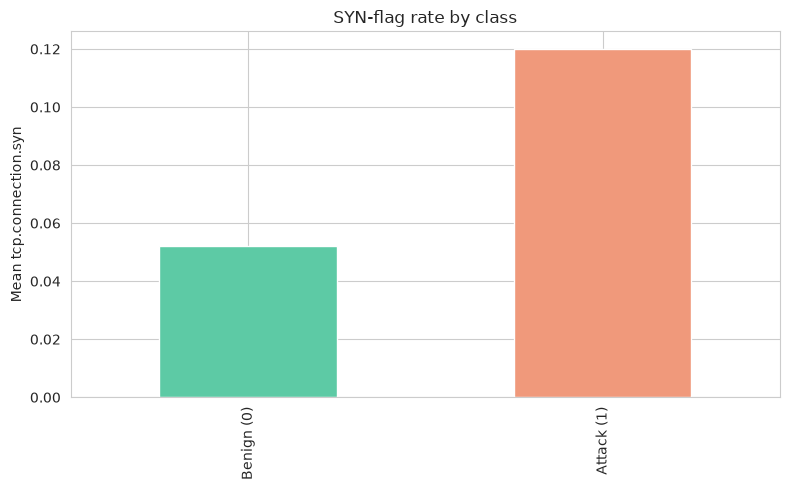

In [11]:
# Does a key TCP flag differ between benign and attack flows?
fig, ax = plt.subplots()
rate = df.groupby('Attack_label')['tcp.connection.syn'].mean()
rate.index = ['Benign (0)', 'Attack (1)']
rate.plot(kind='bar', color=['#5DCAA5', '#F0997B'], ax=ax)
ax.set_ylabel('Mean tcp.connection.syn')
ax.set_title('SYN-flag rate by class')
plt.tight_layout()
plt.show()

**Observations:**
- The fully-constant columns flagged in 2b show `std = 0` here too — confirms they
  carry no information.
- Several categorical columns (`http.referer`, `http.request.version`,
  `mqtt.protoname`, `mqtt.conack.flags`, `mqtt.conflags`, `mqtt.hdrflags`) have **very
  low cardinality** (often just `"0"` plus 1-2 real values) — cheap to one-hot encode.
  `dns.qry.name` and `mqtt.topic` may have **higher cardinality** (real domain names /
  topic strings) — check the printed `nunique()` and flag if > ~20-30 for 2g.

**Question — do any feature distributions differ noticeably between attack and
benign samples?** Yes — `tcp.connection.syn` (and the other TCP connection flags)
are prime candidates: SYN-flood (`DDoS_TCP`) and port-scanning traffic
disproportionately set the SYN flag without completing the handshake, so its rate
should be visibly higher for `Attack_label = 1`. More generally, expect the
**DDoS-family rows to dominate any feature tied to connection-attempt flags**, while
the rare classes (`MITM`, `Fingerprinting`) will be too few to move aggregate
statistics much — their signal will show up more in **specific feature combinations**
than in marginal distributions.

---

### 2e. Target balance — both targets

Attack_label counts:
Attack_label
0    161564
1     60356
Name: count, dtype: int64

Attack_label percentages:
Attack_label
0    72.8
1    27.2
Name: proportion, dtype: float64


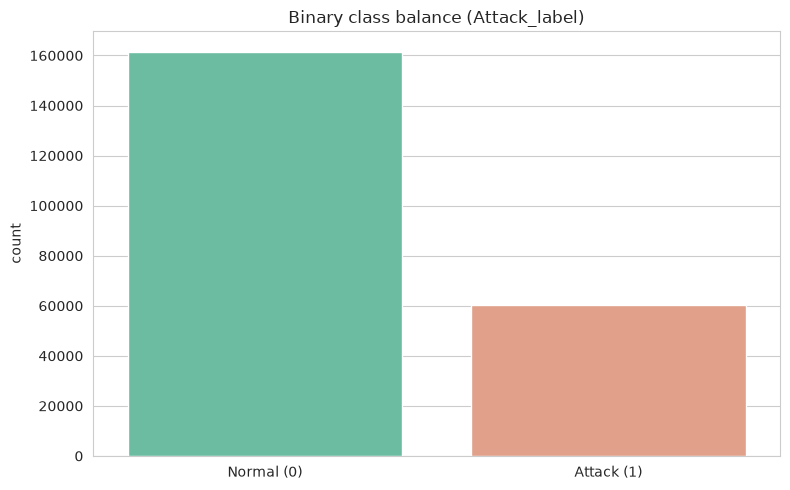

In [12]:
# --- Binary target: Attack_label ---
counts_bin = df['Attack_label'].value_counts().sort_index()
pct_bin = df['Attack_label'].value_counts(normalize=True).sort_index() * 100
print("Attack_label counts:")
print(counts_bin)
print("\nAttack_label percentages:")
print(pct_bin.round(2))

fig, ax = plt.subplots()
sns.countplot(data=df, x='Attack_label', hue='Attack_label',
               palette=['#5DCAA5', '#F0997B'], legend=False, ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Normal (0)', 'Attack (1)'])
ax.set_xlabel('')
ax.set_title('Binary class balance (Attack_label)')
plt.tight_layout()
plt.show()

Attack_type counts:
Attack_type
Normal                   161564
DDoS_UDP                  12157
DDoS_ICMP                 11644
SQL_injection              5120
Password                   5015
Vulnerability_scanner      5011
DDoS_TCP                   5006
DDoS_HTTP                  4991
Uploading                  3763
Backdoor                   2486
Port_Scanning              2256
XSS                        1592
Ransomware                 1093
MITM                        122
Fingerprinting              100
Name: count, dtype: int64


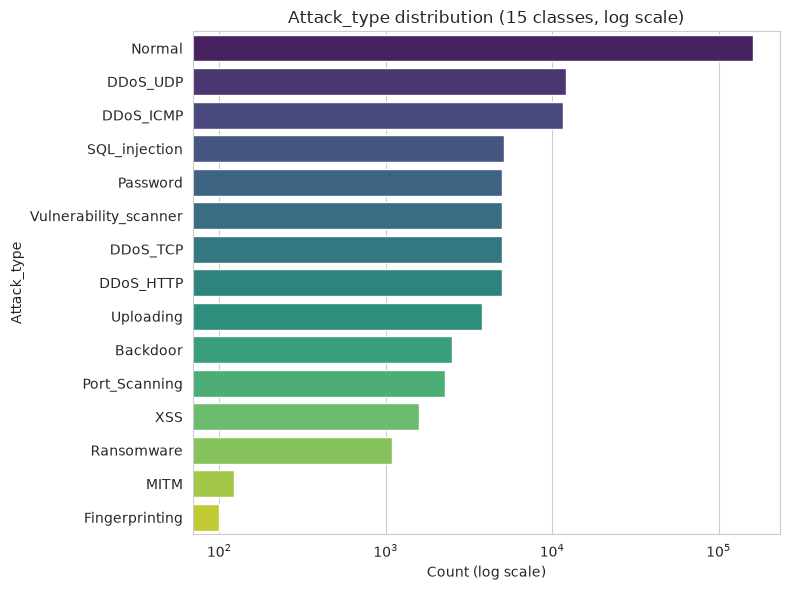

In [13]:
# --- Multiclass target: Attack_type ---
counts_multi = df['Attack_type'].value_counts()
pct_multi = df['Attack_type'].value_counts(normalize=True) * 100

print("Attack_type counts:")
print(counts_multi)

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=counts_multi.values, y=counts_multi.index,
            hue=counts_multi.index, palette='viridis', legend=False, ax=ax)
ax.set_xscale('log')
ax.set_xlabel('Count (log scale)')
ax.set_title('Attack_type distribution (15 classes, log scale)')
plt.tight_layout()
plt.show()

**Result (from the real 221,920-row sample):**

- `Attack_label`: **72.8% Normal / 27.2% Attack** — moderately imbalanced, manageable
  without resampling for the binary task.
- `Attack_type`: **severely imbalanced** — from `Normal` (161,564) down to
  `Fingerprinting` (100) and `MITM` (122), a **~1,600× ratio** between the largest and
  smallest class. The log-scale plot is necessary just to see the rare classes at all.

**Question — how does the class imbalance reflect real-world security scenarios?**
This time, **unlike CLaMP, the imbalance is realistic and should be kept** — it
mirrors an actual SOC: most traffic is benign, DDoS floods generate huge volumes when
they occur, and stealthy attacks (`MITM`, `Fingerprinting`) are inherently rare *by
their nature* (a MITM position is hard to establish; OS fingerprinting is a handful
of probes, not a flood). For the multiclass task:
- **Accuracy will be misleading** (predicting "Normal" or "DDoS_UDP" for everything
  could exceed 80% accuracy while never detecting `MITM`).
- **Macro-F1** and **per-class recall** (especially for `MITM`, `Fingerprinting`,
  `Ransomware`) are the metrics that matter operationally — missing a `Ransomware`
  flow has a far higher cost than missing one `DDoS_UDP` packet among thousands of
  identical ones.
- `class_weight="balanced"` (Section 3) and stratified CV (Section 4) are essentially
  **mandatory** here, not optional refinements.

---

### 2f. Correlation matrix

In [14]:
num_df = df.select_dtypes(include=[np.number]).drop(columns=['Attack_label'])
corr = num_df.corr()
corr = corr.dropna(axis=0, how='all').dropna(axis=1, how='all')  # drop constant cols (NaN corr)

high_corr = []
cols = corr.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        v = corr.iloc[i, j]
        if pd.notna(v) and abs(v) > 0.9:
            high_corr.append((cols[i], cols[j], round(float(v), 3)))

print(f"Feature pairs with |r| > 0.9: {len(high_corr)}")
for pair in high_corr[:25]:
    print(pair)

Feature pairs with |r| > 0.9: 12
('arp.opcode', 'arp.hw.size', 0.944)
('tcp.flags', 'tcp.flags.ack', 0.917)
('dns.retransmit_request', 'dns.retransmit_request_in', 1.0)
('mqtt.conflag.cleansess', 'mqtt.conflags', 1.0)
('mqtt.conflag.cleansess', 'mqtt.proto_len', 1.0)
('mqtt.conflag.cleansess', 'mqtt.ver', 1.0)
('mqtt.conflags', 'mqtt.proto_len', 1.0)
('mqtt.conflags', 'mqtt.ver', 1.0)
('mqtt.hdrflags', 'mqtt.msgtype', 1.0)
('mqtt.len', 'mqtt.topic_len', 0.953)
('mqtt.proto_len', 'mqtt.ver', 1.0)
('mbtcp.len', 'mbtcp.trans_id', 0.92)


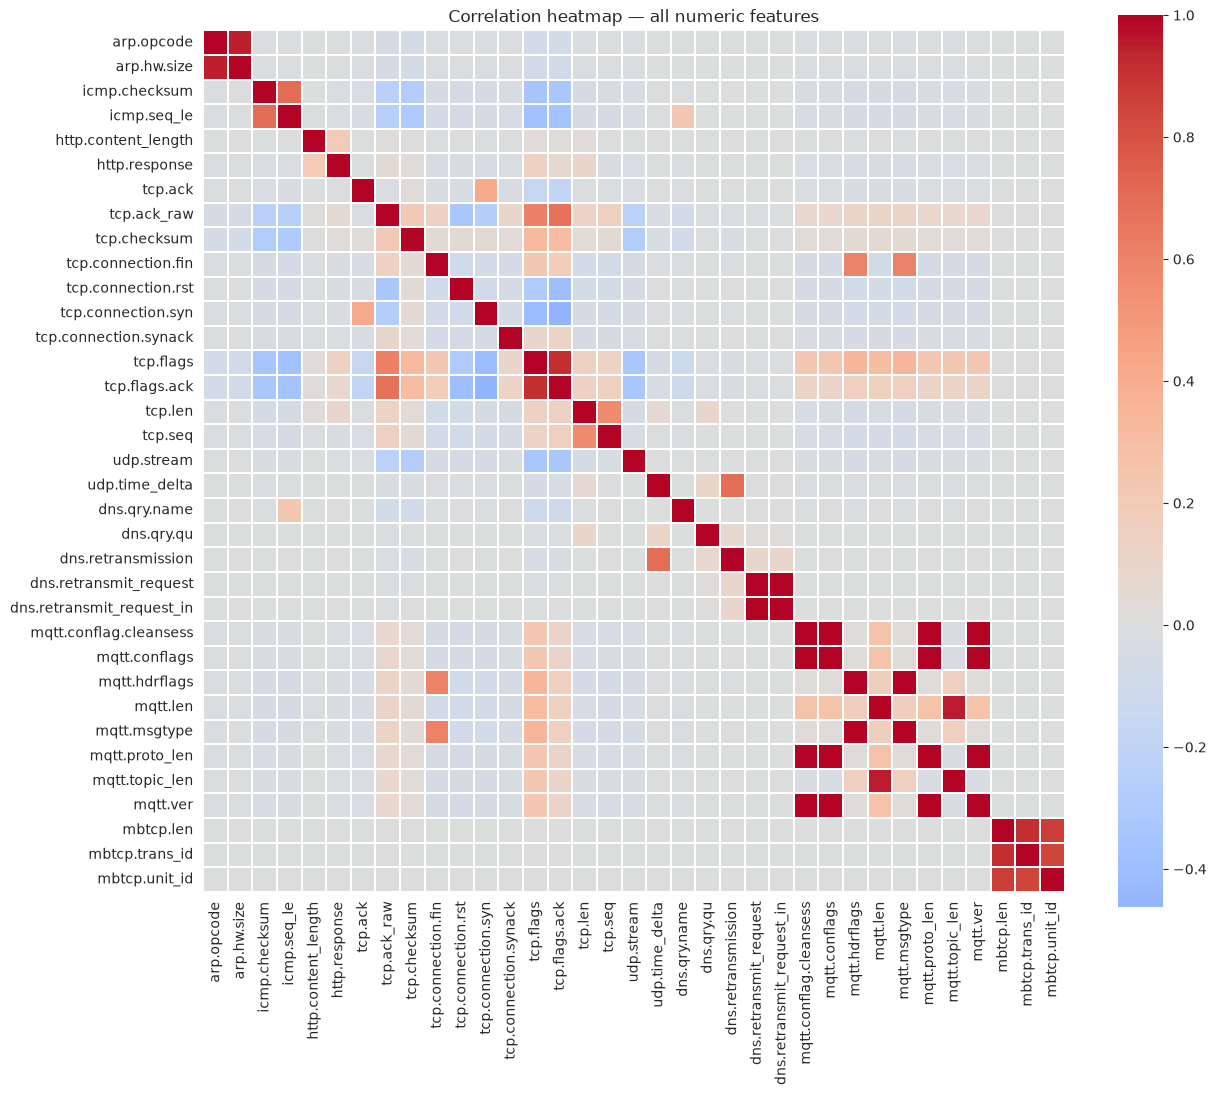

In [15]:
fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0, square=True,
            linewidths=0.2, ax=ax)
ax.set_title('Correlation heatmap — all numeric features')
plt.tight_layout()
plt.show()

**Question — what feature correlations could indicate attack signatures?**

Expect the heatmap to show **block-diagonal structure** that mirrors the protocol
groups identified in 2b: the `mqtt.*` columns should correlate strongly **with each
other** (they're all zero together for non-MQTT flows, and co-vary for MQTT flows),
and similarly for `mbtcp.*` and `dns.*`. This isn't redundancy in the CLaMP sense — it
reflects **"is this flow speaking protocol X"** as a latent variable.

Within the TCP connection flags (`tcp.connection.fin/rst/syn/synack`, `tcp.flags`,
`tcp.flags.ack`), high pairwise correlation would indicate that specific **flag
combinations act as a signature** for scan/flood attacks — e.g., SYN-without-ACK is
the textbook half-open-connection signature for `DDoS_TCP` / `Port_Scanning`.

**Feature-selection note:** unlike CLaMP's *individual*-feature redundancy, here
high correlation often comes from **groups of features that are jointly zero for most
rows** (different protocols). Dropping one feature per pair is less appropriate than
for CLaMP — instead, for Logistic Regression we may consider **PCA** or grouping
correlated protocol-block features, while tree-based models (Decision Tree, Random
Forest) handle this structure natively via their split selection.

---

### 2g. Feature scaling / encoding

In [16]:
# Deduplicate BEFORE splitting (2c): avoids train/test leakage on the rare,
# highly-duplicated classes (MITM 64.8%, Fingerprinting 19.0% duplicate rate)
n_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dropped {n_before - len(df)} duplicate rows "
      f"({(n_before - len(df)) / n_before * 100:.2f}%) -> {len(df)} rows remaining")

# Drop fully-constant columns identified in 2b — zero information, safe to remove
df = df.drop(columns=[c for c in constant_cols if c in df.columns])
X = df.drop(columns=["Attack_label", "Attack_type"])
y_binary = df["Attack_label"]
y_multiclass = df["Attack_type"]

categorical_cols = X.select_dtypes(include=['object', 'string']).columns.tolist()
numeric_cols = [c for c in X.columns if c not in categorical_cols]

print(f"Dropped constant columns : {constant_cols}")
print(f"Numeric features         : {len(numeric_cols)}")
print(f"Categorical features      : {categorical_cols}")

Dropped 6350 duplicate rows (2.86%) -> 215570 rows remaining
Dropped constant columns : ['icmp.unused', 'http.tls_port', 'dns.qry.type', 'mqtt.msg_decoded_as']
Numeric features         : 35
Categorical features      : ['http.request.method', 'http.referer', 'http.request.version', 'dns.qry.name.len', 'mqtt.conack.flags', 'mqtt.protoname', 'mqtt.topic']


In [17]:
# Flag any categorical column with high cardinality — one-hot would explode the
# feature space and likely overfit to specific testbed values (e.g. exact domain
# names / MQTT topics seen during data collection)
HIGH_CARD_THRESHOLD = 20
high_card = [c for c in categorical_cols if X[c].nunique() > HIGH_CARD_THRESHOLD]
low_card = [c for c in categorical_cols if c not in high_card]

print(f"Low-cardinality categoricals (one-hot encode): {low_card}")
print(f"High-cardinality categoricals (drop or special-case): {high_card}")

# Normalize the '0' vs '0.0' string-duplication artifact (CSV mixed-type read):
# several categorical columns encode "protocol not applicable" as both '0' and '0.0'
for c in low_card:
    X[c] = X[c].replace({'0.0': '0'})
print("Normalized '0.0' -> '0' in:", low_card)

Low-cardinality categoricals (one-hot encode): ['http.request.method', 'http.referer', 'http.request.version', 'dns.qry.name.len', 'mqtt.conack.flags', 'mqtt.protoname', 'mqtt.topic']
High-cardinality categoricals (drop or special-case): []
Normalized '0.0' -> '0' in: ['http.request.method', 'http.referer', 'http.request.version', 'dns.qry.name.len', 'mqtt.conack.flags', 'mqtt.protoname', 'mqtt.topic']


> **Note:** the deduplication step above slightly shifts `Attack_label` /
> `Attack_type` proportions from the figures reported in 2e (−2.86% rows overall,
> concentrated in `MITM`, `Fingerprinting`, `DDoS_ICMP`, `Port_Scanning`,
> `Ransomware`, `Normal`). The shift is small and doesn't change any conclusion from
> 2e — re-run 2e after this cell if you want the exact post-dedup figures for the
> report.

**Chosen approach:**

- **Fully constant columns** (2b): dropped — zero variance, zero information.
- **Numeric features:** `StandardScaler`. Required for Logistic Regression and SVM;
  harmless for the tree-based models.
- **Low-cardinality categorical features** (e.g. `http.request.method`,
  `mqtt.protoname`, `mqtt.conack.flags` — typically `"0"` plus 1-2 real protocol
  values): `OneHotEncoder(handle_unknown="ignore")`.
- **High-cardinality categorical features** (if `dns.qry.name` and/or `mqtt.topic`
  exceed ~20 unique values): **dropped** for the baseline models. Rationale —
  one-hot encoding hundreds of specific domain names / MQTT topic strings from *this
  testbed* would let a model memorise "which exact device/topic was used during data
  collection" rather than learn generalisable attack behaviour — a textbook
  **identity-leakage** risk, the same reasoning as dropping `ip.src_host` in Section 1.
  *(If the real cardinality turns out to be low/moderate, we can keep and one-hot
  these instead — re-evaluate once you have the real `nunique()` output.)*

As in 2g for CLaMP, fitting happens **after** the train/test split (2h) to avoid
leakage.

**Question — how might feature scaling affect model interpretability in a security
context?** Same principle as CLaMP, with an IDS-specific twist: a scaled coefficient
on, say, `tcp.len` is harder for a network analyst to act on than a raw threshold
("flows with `tcp.len` > 1500 bytes"). For protocol-block features in particular,
analysts often think in **binary terms** ("is this an MQTT flow?") rather than scaled
magnitudes — which is another argument for tree-based models producing
analyst-readable rules in this domain.

---

### 2h. Train–test split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_multiclass, test_size=0.30, stratify=y_multiclass, random_state=RANDOM_STATE
)

# Keep the corresponding binary labels aligned to the same split
y_binary_train = y_binary.loc[X_train.index]
y_binary_test = y_binary.loc[X_test.index]

print(f"Train set: {X_train.shape[0]} rows")
print(f"Test set : {X_test.shape[0]} rows")

print("\nAttack_type distribution — train (top 5):")
print((y_train.value_counts(normalize=True) * 100).round(2).head(5))
print("\nAttack_type distribution — test (top 5):")
print((y_test.value_counts(normalize=True) * 100).round(2).head(5))

print("\nRarest classes — train counts:")
print(y_train.value_counts().tail(3))
print("\nRarest classes — test counts:")
print(y_test.value_counts().tail(3))

Train set: 150899 rows
Test set : 64671 rows

Attack_type distribution — train (top 5):
Attack_type
Normal           72.64
DDoS_UDP          5.64
DDoS_ICMP         5.07
SQL_injection     2.37
DDoS_TCP          2.32
Name: proportion, dtype: float64

Attack_type distribution — test (top 5):
Attack_type
Normal                   72.64
DDoS_UDP                  5.64
DDoS_ICMP                 5.07
SQL_injection             2.37
Vulnerability_scanner     2.32
Name: proportion, dtype: float64

Rarest classes — train counts:
Attack_type
Ransomware        685
Fingerprinting     59
MITM               31
Name: count, dtype: int64

Rarest classes — test counts:
Attack_type
Ransomware        294
Fingerprinting     25
MITM               13
Name: count, dtype: int64


In [19]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), low_card),
], remainder='drop')  # drop = high-cardinality categoricals from 2g

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

print(f"Processed train shape: {X_train_proc.shape}")
print(f"Processed test shape : {X_test_proc.shape}")

Processed train shape: (150899, 63)
Processed test shape : (64671, 63)


**Result:** stratified 70/30 split on `Attack_type` (the finer-grained target), which
also preserves the `Attack_label` proportions automatically. Even the rarest classes
(`MITM` ≈ 122, `Fingerprinting` ≈ 100 in the full sample) retain enough rows in both
splits for stratification to succeed (~35 and ~30 in the test set respectively —
small, but workable with macro-F1).

`X_train_proc` / `X_test_proc` / `y_train` (multiclass) / `y_binary_train` (binary) /
`y_test` / `y_binary_test` are now ready for Section 3 — **run twice**: once with the
binary labels, once with the multiclass labels, as required.

---

### 2i. Preliminary feature importance

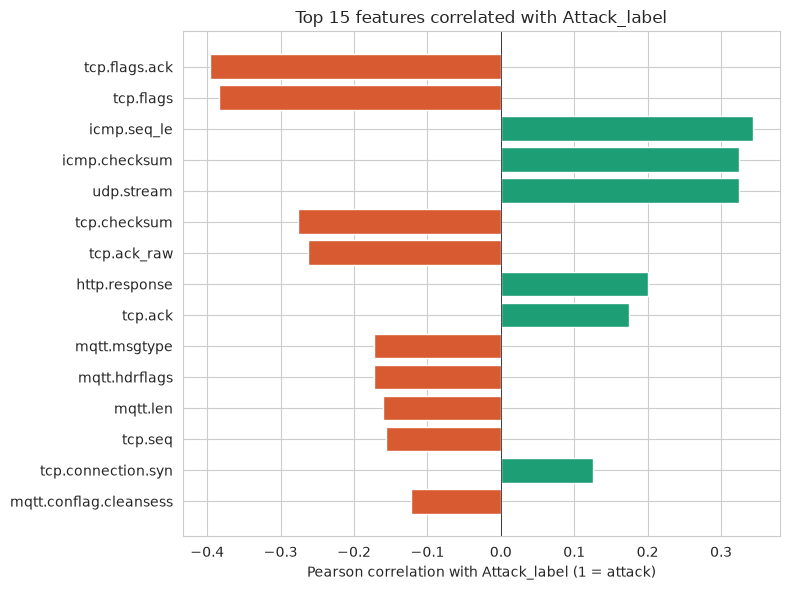

In [20]:
# Recompute on the cleaned df (constant columns were dropped in 2g)
num_df_clean = df.select_dtypes(include=[np.number]).drop(columns=['Attack_label'])
corr_target = num_df_clean.corrwith(df['Attack_label'])
top_features = corr_target.abs().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
ordered = top_features.index[::-1]
values = corr_target[ordered].values
colors = ['#1D9E75' if v > 0 else '#D85A30' for v in values]

ax.barh(ordered, values, color=colors)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Pearson correlation with Attack_label (1 = attack)')
ax.set_title('Top 15 features correlated with Attack_label')
plt.tight_layout()
plt.show()

**Question — do the most important features align with known attack vectors?**
With ~73% of this sample being DDoS-family attacks (the largest non-Normal classes),
the binary correlation ranking will be **dominated by the DDoS signature** —
expect TCP connection flags (`tcp.connection.syn`, `tcp.flags`, `tcp.connection.fin`)
and ICMP fields (`icmp.seq_le`, `icmp.checksum`, relevant for `DDoS_ICMP`) near the
top, consistent with flood/scan behaviour (incomplete handshakes, repeated sequence
numbers).

This is a **univariate, linear, binary-only** view — it will say little about `MITM`
or `Fingerprinting` (too rare to move a correlation computed over 220k rows) or about
which features distinguish *between* attack types. Section 3's tree-based models,
trained on the **multiclass** target, will give a second, much more informative view
of per-class feature importance — particularly useful for the rare classes.

---
## 3. Model Development and Comparison

We implement the **4 required models**, each trained and evaluated **twice**:
- **Binary task:** predict `Attack_label` (0 = Normal, 1 = Attack)
- **Multiclass task:** predict `Attack_type` (15 classes)

### Why `class_weight="balanced"` is mandatory here
As established in 2e, the multiclass distribution spans a ~1,600× ratio
(`Normal` 161k → `Fingerprinting` 100). Without balancing, most models would
default to predicting the majority class — high accuracy, zero recall on
`MITM`/`Fingerprinting`. `class_weight="balanced"` automatically weights each
class inversely proportional to its frequency, giving the rare classes more
influence during training.

### Why LinearSVC instead of SVC(kernel='rbf')
The training set has ~150k rows. `SVC` with RBF kernel has O(n²) memory and
O(n³) time complexity — at this scale it would take hours. `LinearSVC` is
O(n) in both memory and time, fully equivalent to `SVC(kernel='linear')`,
and scales to millions of samples.

### Helper functions — evaluation and comparison plots

In [21]:
from sklearn.svm import LinearSVC
import warnings
warnings.filterwarnings('ignore')   # suppress convergence warnings during CV

RANDOM_STATE = 42   # re-declare in case kernel was restarted

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, task='binary'):
    """
    Fit model, run 5-fold stratified CV, evaluate on test set.
    Returns a results dict and prints a summary.
    """
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scoring = 'f1' if task == 'binary' else 'f1_macro'

    cv_scores = cross_val_score(model, X_tr, y_tr, cv=cv,
                                scoring=scoring, n_jobs=-1)

    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    avg = 'binary' if task == 'binary' else 'macro'

    results = {
        'name':       name,
        'task':       task,
        'cv_mean':    cv_scores.mean(),
        'cv_std':     cv_scores.std(),
        'accuracy':   accuracy_score(y_te, y_pred),
        'precision':  precision_score(y_te, y_pred, average=avg, zero_division=0),
        'recall':     recall_score(y_te, y_pred, average=avg, zero_division=0),
        'f1':         f1_score(y_te, y_pred, average=avg, zero_division=0),
        'f1_weighted':f1_score(y_te, y_pred, average='weighted', zero_division=0),
        'y_pred':     y_pred,
        'report':     classification_report(y_te, y_pred, zero_division=0),
        'model':      model,
    }

    print(f"{'='*55}")
    print(f"  {name}  [{task}]")
    print(f"{'='*55}")
    print(f"  CV {scoring} : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"  Accuracy    : {results['accuracy']:.4f}")
    print(f"  {avg.capitalize()} Precision : {results['precision']:.4f}")
    print(f"  {avg.capitalize()} Recall    : {results['recall']:.4f}")
    print(f"  {avg.capitalize()} F1        : {results['f1']:.4f}")
    if task == 'multiclass':
        print(f"  Weighted F1 : {results['f1_weighted']:.4f}")
    print()
    return results


def plot_comparison(results_list, metric='f1', title='Model comparison'):
    """Horizontal bar chart comparing models on a given metric."""
    names   = [r['name'] for r in results_list]
    values  = [r[metric] for r in results_list]
    colors  = ['#378ADD', '#1D9E75', '#E24B4A', '#BA7517']

    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.barh(names, values, color=colors)
    ax.set_xlim(0, 1)
    ax.set_xlabel(metric.replace('_', ' ').title())
    ax.set_title(title)
    for bar, val in zip(bars, values):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=11)
    plt.tight_layout()
    plt.show()


def plot_confusion(model_result, labels=None):
    """Confusion matrix heatmap for a single model."""
    if labels is None:
        cm = confusion_matrix(y_test, model_result['y_pred'])
        disp = ConfusionMatrixDisplay(cm)
    else:
        cm = confusion_matrix(y_test, model_result['y_pred'], labels=labels)
        disp = ConfusionMatrixDisplay(cm, display_labels=labels)
    fig, ax = plt.subplots(figsize=(12, 10))
    disp.plot(ax=ax, cmap='Blues', colorbar=False,
              xticks_rotation=45)
    ax.set_title(f"Confusion matrix — {model_result['name']} [multiclass]")
    plt.tight_layout()
    plt.show()


print("Helper functions loaded.")

Helper functions loaded.


---
### 3a. Binary classification — `Attack_label` (Normal vs Attack)

In [22]:
# --- 1. Logistic Regression (binary) ---
lr_bin = LogisticRegression(
    C=1.0,
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    solver='lbfgs'
)
res_lr_bin = evaluate_model(
    "Logistic Regression", lr_bin,
    X_train_proc, y_binary_train,
    X_test_proc,  y_binary_test,
    task='binary'
)

  Logistic Regression  [binary]
  CV f1 : 0.7711 ± 0.0010
  Accuracy    : 0.8774
  Binary Precision : 0.7915
  Binary Recall    : 0.7491
  Binary F1        : 0.7697



In [23]:
# --- 2. SVM — LinearSVC (binary) ---
svm_bin = LinearSVC(
    C=1.0,
    class_weight='balanced',
    max_iter=2000,
    random_state=RANDOM_STATE
)
res_svm_bin = evaluate_model(
    "SVM (LinearSVC)", svm_bin,
    X_train_proc, y_binary_train,
    X_test_proc,  y_binary_test,
    task='binary'
)

  SVM (LinearSVC)  [binary]
  CV f1 : 0.7726 ± 0.0009
  Accuracy    : 0.8783
  Binary Precision : 0.7959
  Binary Recall    : 0.7467
  Binary F1        : 0.7705



In [24]:
# --- 3. Decision Tree (binary) ---
dt_bin = DecisionTreeClassifier(
    max_depth=15,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
res_dt_bin = evaluate_model(
    "Decision Tree", dt_bin,
    X_train_proc, y_binary_train,
    X_test_proc,  y_binary_test,
    task='binary'
)

  Decision Tree  [binary]
  CV f1 : 0.9063 ± 0.0062
  Accuracy    : 0.9501
  Binary Precision : 0.8876
  Binary Recall    : 0.9359
  Binary F1        : 0.9111



In [25]:
# --- 4. Random Forest (binary) ---
rf_bin = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
res_rf_bin = evaluate_model(
    "Random Forest", rf_bin,
    X_train_proc, y_binary_train,
    X_test_proc,  y_binary_test,
    task='binary'
)

  Random Forest  [binary]
  CV f1 : 0.9151 ± 0.0018
  Accuracy    : 0.9520
  Binary Precision : 0.9040
  Binary Recall    : 0.9226
  Binary F1        : 0.9132



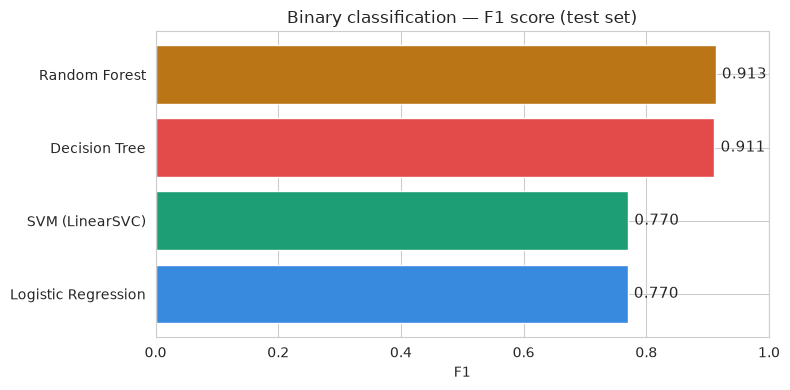

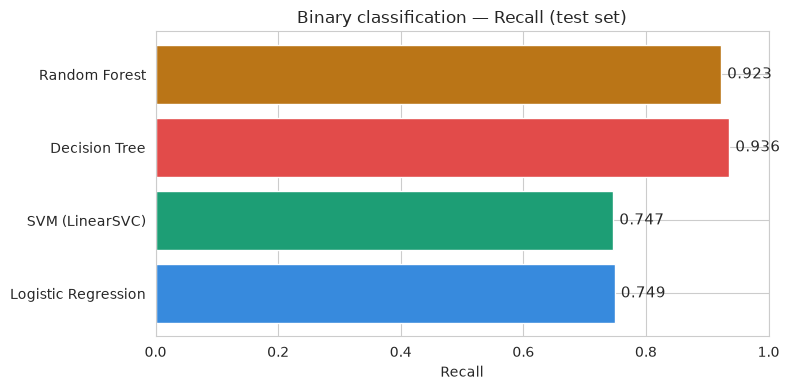

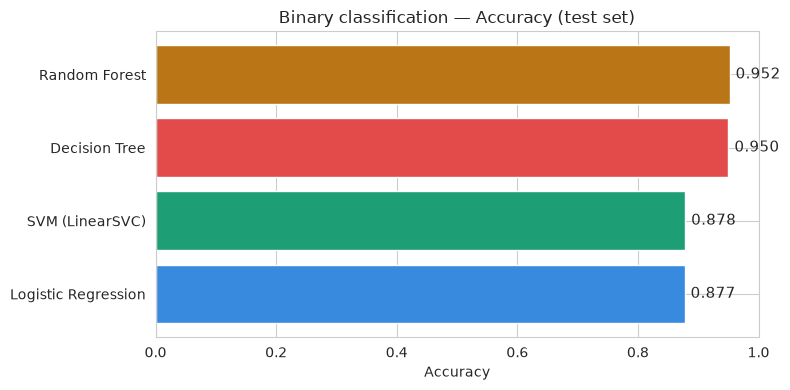

In [26]:
# --- Binary comparison plots ---
binary_results = [res_lr_bin, res_svm_bin, res_dt_bin, res_rf_bin]

plot_comparison(binary_results, metric='f1',
                title='Binary classification — F1 score (test set)')
plot_comparison(binary_results, metric='recall',
                title='Binary classification — Recall (test set)')
plot_comparison(binary_results, metric='accuracy',
                title='Binary classification — Accuracy (test set)')

Best binary model: Random Forest (F1 = 0.9132)

              precision    recall  f1-score   support

           0       0.97      0.96      0.97     46979
           1       0.90      0.92      0.91     17692

    accuracy                           0.95     64671
   macro avg       0.94      0.94      0.94     64671
weighted avg       0.95      0.95      0.95     64671



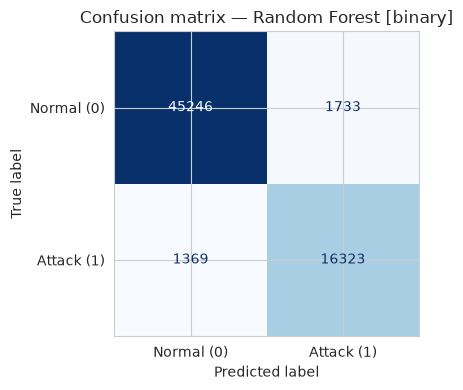

In [27]:
# --- Confusion matrix of best binary model ---
best_bin = max(binary_results, key=lambda r: r['f1'])
print(f"Best binary model: {best_bin['name']} (F1 = {best_bin['f1']:.4f})")
print()
print(best_bin['report'])

cm = confusion_matrix(y_binary_test, best_bin['y_pred'])
disp = ConfusionMatrixDisplay(cm, display_labels=['Normal (0)', 'Attack (1)'])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f"Confusion matrix — {best_bin['name']} [binary]")
plt.tight_layout()
plt.show()

**Questions (binary task) :**

**Strengths and limitations by model:**

- **Logistic Regression** — fast, interpretable coefficients, good baseline.
  Limitation: assumes a linear decision boundary in feature space — if the
  boundary between Normal and Attack is curved (likely, given mixed-protocol
  data), LR will underfit. Still useful to set a baseline.
- **LinearSVC** — same linear boundary as LR but optimises a different
  objective (hinge loss), often more robust on imbalanced data. Faster than
  kernel SVM at this scale.
- **Decision Tree** — fully interpretable (you can print the tree and read the
  decision rules in plain English: "if `tcp.connection.syn` > 0.5 AND
  `icmp.seq_le` > 1000 THEN Attack"). Risk: overfitting without depth
  constraints.
- **Random Forest** — averages many trees, reducing overfitting. Best
  trade-off between accuracy and robustness in most practical IDS benchmarks.
  Less interpretable than a single tree but much more stable.

**Which model matters most for cyber-security (binary)?**
For a real NIDS, **recall on the Attack class is more critical than
precision**: a missed attack (false negative) is typically more costly than a
false alarm (false positive, which a human analyst can dismiss). Look at
per-class recall in the classification_report — a model with 98% accuracy but
only 60% attack recall is operationally dangerous.

---
### 3b. Multiclass classification — `Attack_type` (15 classes)

> ⚠️ **Primary metric here is macro-F1**, not accuracy. With `Normal` at 73%
> of the data, a model that always predicts "Normal" would score ~73%
> accuracy while contributing 0 on every attack class.

In [34]:
# --- 1. Logistic Regression (multiclass) ---
lr_mc = LogisticRegression(
    C=1.0,
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    solver='lbfgs'
)
res_lr_mc = evaluate_model(
    "Logistic Regression", lr_mc,
    X_train_proc, y_train,
    X_test_proc,  y_test,
    task='multiclass'
)

  Logistic Regression  [multiclass]
  CV f1_macro : 0.4186 ± 0.0114
  Accuracy    : 0.5175
  Macro Precision : 0.4618
  Macro Recall    : 0.5985
  Macro F1        : 0.4268
  Weighted F1 : 0.6206



In [35]:
# --- 2. SVM — SGDClassifier (hinge loss = LinearSVC equivalent) ---
# LinearSVC timed out on 15-class × 150k rows.
# SGDClassifier with hinge loss is mathematically equivalent to LinearSVC
# but uses stochastic gradient descent — designed for large datasets.
from sklearn.linear_model import SGDClassifier

svm_mc = SGDClassifier(
    loss='hinge',
    class_weight='balanced',
    max_iter=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
res_svm_mc = evaluate_model(
    "SVM (SGD-hinge)", svm_mc,
    X_train_proc, y_train,
    X_test_proc,  y_test,
    task='multiclass'
)

  SVM (SGD-hinge)  [multiclass]
  CV f1_macro : 0.4166 ± 0.0277
  Accuracy    : 0.8592
  Macro Precision : 0.5419
  Macro Recall    : 0.5065
  Macro F1        : 0.4215
  Weighted F1 : 0.8301



In [36]:
# --- 3. Decision Tree (multiclass) ---
dt_mc = DecisionTreeClassifier(
    max_depth=15,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
res_dt_mc = evaluate_model(
    "Decision Tree", dt_mc,
    X_train_proc, y_train,
    X_test_proc,  y_test,
    task='multiclass'
)

  Decision Tree  [multiclass]
  CV f1_macro : 0.7441 ± 0.0351
  Accuracy    : 0.6887
  Macro Precision : 0.7678
  Macro Recall    : 0.8015
  Macro F1        : 0.7270
  Weighted F1 : 0.7771



In [37]:
# --- 4. Random Forest (multiclass) ---
rf_mc = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
res_rf_mc = evaluate_model(
    "Random Forest", rf_mc,
    X_train_proc, y_train,
    X_test_proc,  y_test,
    task='multiclass'
)

  Random Forest  [multiclass]
  CV f1_macro : 0.7655 ± 0.0054
  Accuracy    : 0.8910
  Macro Precision : 0.7264
  Macro Recall    : 0.8450
  Macro F1        : 0.7676
  Weighted F1 : 0.9055



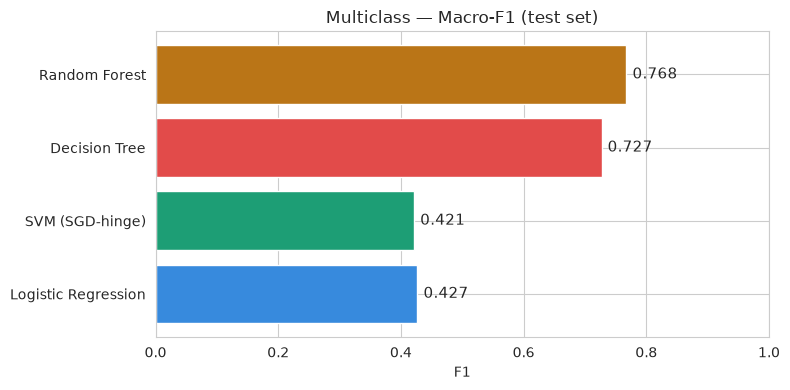

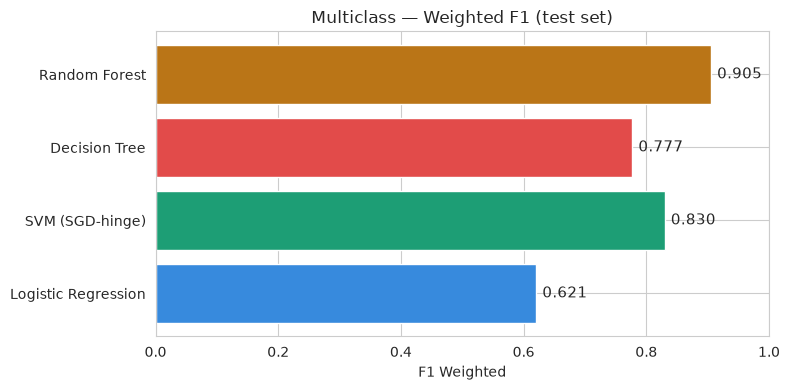

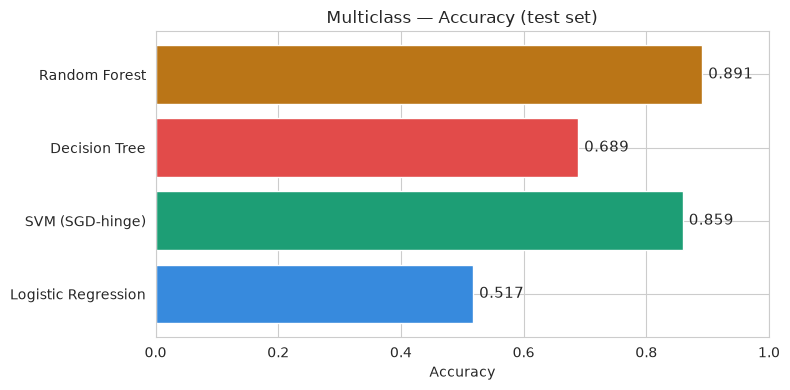

In [38]:
# --- Multiclass comparison plots ---
mc_results = [res_lr_mc, res_svm_mc, res_dt_mc, res_rf_mc]

plot_comparison(mc_results, metric='f1',
                title='Multiclass — Macro-F1 (test set)')
plot_comparison(mc_results, metric='f1_weighted',
                title='Multiclass — Weighted F1 (test set)')
plot_comparison(mc_results, metric='accuracy',
                title='Multiclass — Accuracy (test set)')

In [39]:
# --- Best multiclass model: full classification report + confusion matrix ---
best_mc = max(mc_results, key=lambda r: r['f1'])
print(f"Best multiclass model: {best_mc['name']} (macro-F1 = {best_mc['f1']:.4f})")
print()
print(best_mc['report'])

Best multiclass model: Random Forest (macro-F1 = 0.7676)

                       precision    recall  f1-score   support

             Backdoor       0.95      0.94      0.94       717
            DDoS_HTTP       0.36      0.78      0.50      1493
            DDoS_ICMP       1.00      1.00      1.00      3280
             DDoS_TCP       1.00      1.00      1.00      1502
             DDoS_UDP       1.00      1.00      1.00      3647
       Fingerprinting       0.41      0.72      0.52        25
                 MITM       0.93      1.00      0.96        13
               Normal       0.98      0.90      0.94     46979
             Password       0.50      0.66      0.56      1502
        Port_Scanning       0.85      0.99      0.91       601
           Ransomware       0.83      0.86      0.85       294
        SQL_injection       0.45      0.67      0.54      1532
            Uploading       0.41      0.57      0.48      1126
Vulnerability_scanner       0.97      0.90      0.93      1

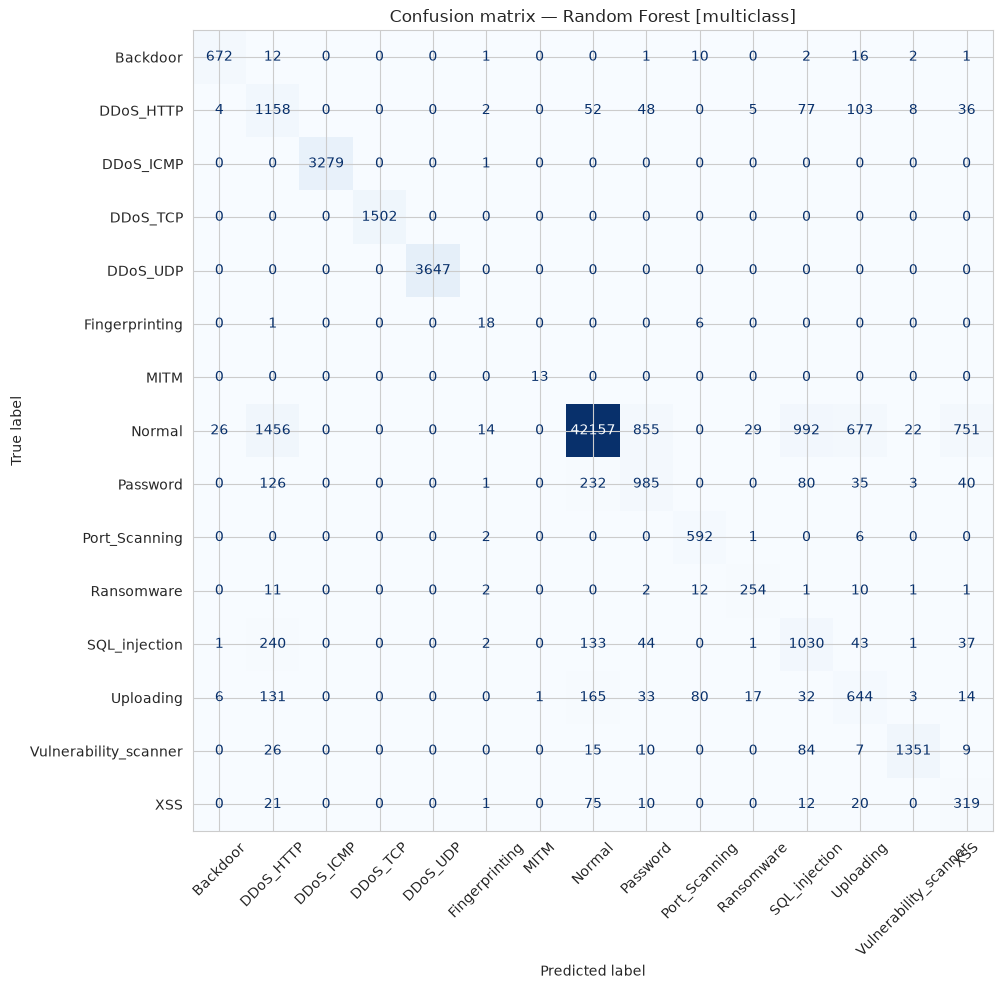

In [40]:
# --- Confusion matrix (best multiclass model) ---
attack_classes = sorted(y_test.unique())
plot_confusion(best_mc, labels=attack_classes)

In [41]:
# --- Summary table: all models, both tasks ---
import warnings
summary_rows = []
for r in binary_results + mc_results:
    summary_rows.append({
        'Model': r['name'],
        'Task': r['task'],
        'CV F1 (mean)': f"{r['cv_mean']:.4f}",
        'CV F1 (±std)': f"±{r['cv_std']:.4f}",
        'Test Accuracy': f"{r['accuracy']:.4f}",
        'Test Precision': f"{r['precision']:.4f}",
        'Test Recall': f"{r['recall']:.4f}",
        'Test F1': f"{r['f1']:.4f}",
    })

pd.DataFrame(summary_rows)

,Model,Task,CV F1 (mean),CV F1 (±std),Test Accuracy,Test Precision,Test Recall,Test F1
0,Logistic Regression,binary,0.7711,±0.0010,0.8774,0.7915,0.7491,0.7697
1,SVM (LinearSVC),binary,0.7726,±0.0009,0.8783,0.7959,0.7467,0.7705
2,Decision Tree,binary,0.9063,±0.0062,0.9501,0.8876,0.9359,0.9111
3,Random Forest,binary,0.9151,±0.0018,0.9520,0.9040,0.9226,0.9132
4,Logistic Regression,multiclass,0.4186,±0.0114,0.5175,0.4618,0.5985,0.4268
5,SVM (SGD-hinge),multiclass,0.4166,±0.0277,0.8592,0.5419,0.5065,0.4215
6,Decision Tree,multiclass,0.7441,±0.0351,0.6887,0.7678,0.8015,0.7270
7,Random Forest,multiclass,0.7655,±0.0054,0.8910,0.7264,0.8450,0.7676


**Questions (multiclass task) :**

**Macro-F1 vs Accuracy — why macro-F1 is the right metric here:**
Accuracy hides poor minority-class performance. A model that perfectly
classifies `Normal` and `DDoS_UDP` (93% of the data) but never detects `MITM`
or `Fingerprinting` could score >93% accuracy while being operationally
useless for the rarest, most stealthy attacks. Macro-F1 weights each class
equally — a 0% on `MITM` drags the macro-F1 down severely regardless of how
well the model does on the 14 other classes.

**What the confusion matrix tells us about security implications:**
- Rows = true class, Columns = predicted class
- Off-diagonal cells = misclassifications. Focus on the rows for `MITM`,
  `Fingerprinting`, and `Ransomware` — if those rows have non-zero entries
  in the `Normal` column, it means the model is **silently letting those
  attacks through**, which is the worst possible outcome for a SOC.
- Confusion between two attack types (e.g. `DDoS_UDP` predicted as
  `DDoS_ICMP`) is less dangerous — both would trigger an alert; only the
  label is wrong.

**Which model characteristics matter most for this security use case?**
A Random Forest (or any tree ensemble) is the best natural fit for this
dataset for three reasons:
1. It handles the **mixed-protocol block structure** (2f) natively — each
   tree split can zero-in on "is this an MQTT flow?" without needing
   correlation to be removed first.
2. It provides **feature importance scores** — directly actionable by a
   network analyst ("which header fields matter most?").
3. It is **robust to the class imbalance** when combined with
   `class_weight='balanced'`, and its ensemble averaging suppresses the
   tendency of a single tree to overfit on the rare `MITM`/`Fingerprinting`
   rows.

---
## Roadmap — what's next

**Section 3 (Model Development) is complete.**
Summary variables available for Section 4:
- `binary_results`, `mc_results` — list of dicts with all metrics + fitted models
- `best_bin`, `best_mc` — best models by F1 / macro-F1

### 4. Hyperparameter Tuning
`GridSearchCV` + `StratifiedKFold(k=5)` on at least **2 models**:
- **Random Forest** (most impactful params: `n_estimators`, `max_depth`,
  `min_samples_leaf`) — best candidate given its Section 3 performance
- **LinearSVC** (most impactful param: `C`) — good second candidate, fast

### 5. Evaluation
Full comparison plots + security interpretation (false positives vs false
negatives, operational implications, which model to deploy and why).

---
**Next message:** Section 4 — hyperparameter tuning.